# **GreenRoute**
#### *Marouchka Heck, Chiara Bifulco, Nour Sarhini and Pamela Sampaa Afaki*

## **I. Introduction**

In the pharmaceutical industry, the synthesis of life-saving drugs often comes with a significant hidden cost: the generation of large amounts of chemical waste. To address this challenge, green chemistry has emerged as a field focused on the design of more sustainable chemical processes. It provides tools that help chemists reduce waste, improve resource efficiency, and minimise environmental impact.  

In practice, a single pharmaceutical molecule can often be synthesised through multiple different pathways. These routes may differ in the number of steps, reagents used, reaction yields, and overall waste production. Although they all lead to the same final product, they are not equally efficient or environmentally friendly. As a result, selecting the optimal synthesis route is a critical challenge, particularly in industrial contexts where processes are implemented at large scale.  

To evaluate and compare these pathways, chemists rely on several key green chemistry metrics such as Atom Economy, Process Mass Intensity (PMI), E-factor, and reaction yield. These indicators provide quantitative measures of how sustainable and efficient a chemical process is. However, interpreting them together can be challenging, as multiple variables must be considered simultaneously. In practice, comparing synthesis pathways is therefore often time-consuming and prone to oversight, highlighting the need for a more systematic and efficient approach to identify the most sustainable route.  


This is why we created **GreenRoute**!  

GreenRoute is a computational tool designed to support the comparison of synthesis pathways in a structured and data-driven way. The objective of this project is to develop a computational framework that enables systematic comparison of multiple synthesis pathways based on green chemistry principles. More specifically, the project aims to:

- Analyse synthesis pathways for four pharmaceutical molecules  
- Compute key green chemistry indicators such as Process Mass Intensity (PMI) and Atom Economy  
- Compare synthetic routes quantitatively using these metrics  
- Evaluate and interpret pathway efficiency and sustainability in a structured way  

In addition, the tool is designed to facilitate interpretation by enabling chemists and engineers to visualise and compare relevant factors through an interactive interface, reducing the need for manual evaluation.  

While this project focuses on pharmaceutical molecules, the same challenges apply broadly to chemical synthesis in general, including the production of polymers, dyes, and other industrial compounds.  

The following cell imports the required libraries and sets up the project paths:

In [14]:
import matplotlib.pyplot as plt
!pip install pandas
!pip install plotly
!pip install nbformat>=4.2.0

import sys
from pathlib import Path

sys.path.insert(0, "../src")
from greenroute import *

DATA_PATH = Path().resolve() / ".." / "data"

ModuleNotFoundError: No module named 'loader'

## **II.Materials and Methods**

## 1. Project Overview and Computational Pipeline

The GreenRoute project is a green chemistry decision-support platform designed to evaluate and compare different chemical synthesis pathways for the same target molecule, allowing the user to determine which pathway is the most suitable for synthesis. The system takes an Excel workbook containing route summaries, reaction steps, and material data for multiple synthesis routes, then processes this information through a computational pipeline to identify the most sustainable and efficient pathway according to green chemistry principles.

The pipeline begins with a data loading stage, where the Excel sheets are imported into Pandas DataFrames. The data is then cleaned and standardised in order to prepare the tables for analysis. After cleaning, a validation step ensures that all required columns are present, that Route_ID values are consistent, and that each reaction step is complete and correctly defined.

Once validated, the system transforms the spreadsheet data into structured chemistry objects representing materials, reaction steps, and complete synthesis routes. These route objects are then used to calculate green chemistry indicators such as Atom Economy, Process Mass Intensity (PMI), E-Factor, and overall yield. The calculations are normalised across the full synthetic pathway to allow fair comparison between routes with different numbers of steps and yields.

Finally, the calculated results are compiled into a comparison table (Excel format) and exported for visualisation in a Streamlit web interface. This interface allows users to visualise molecular structures and route information, compare synthesis pathways side-by-side, and identify the most sustainable synthetic strategy based on quantitative green chemistry metrics.

## 2. Data Collection and Dataset Construction

### 2.1 Data Sources and Literature Curation

The dataset was constructed using information extracted from scientific research papers and industrial publications related to pharmaceutical synthesis pathways of Ibuprofen, Artemisinin, Sertraline, and Sitagliptin. Relevant experimental and sustainability data were collected from these sources, including reaction yields, material quantities, solvent usage, hazard information, and published green chemistry metrics.

### 2.2 Structure of the Excel Workbook

The data used in this project consists of an Excel workbook composed of three sheets: **Route Summary**, **Step Data**, and **Materials**.
- The **Route Summary** sheet contains general information about each synthesis pathway, including the target product, number of steps, overall yield, and reported green chemistry metrics such as Atom Economy, PMI, and E-Factor (used as reference values when experimental data is missing).
- The **Step Data** sheet describes each reaction step within a synthesis route, including reaction details, intermediate products, molecular weights, and yields.
- The **Materials** sheet contains detailed information about the reactants, reagents, catalysts, and solvents used in each step, together with their masses, stoichiometric coefficients, solvent assessments, and hazard scores.

The workbook structure was designed so that companies or researchers can upload their own experimental datasets or Excel workbooks following the same format, allowing the program to process their synthesis data and automatically analyse the sustainability and green chemistry performance of their reaction pathways.

## 3. Data Loading and Preprocessing

### 3.1 Loading Excel Data with Pandas

The first step of the GreenRoute pipeline is data loading and organisation. The project uses a dedicated loader module that reads the Excel workbook and separates its three sheets (Route Summary, Step Data, and Materials) into individual Pandas DataFrames using functions such as `pd.read_excel()` and `pd.ExcelFile()`. DataFrames were chosen because they provide a simple and practical way to manipulate structured tabular data while remaining easy to read, filter, and process.

To complete this step, the project also relies on **openpyxl**, a Python library used internally by Pandas to read and handle `.xlsx` Excel files.

In [ ]:
route_summary_df, step_data_df, materials_df = load_excel_sheets(DATA_PATH / "Excel-data2.xlsx")

print(f"✅ Loaded successfully!")
print(f"   • Route Summary : {route_summary_df.shape[0]} rows × {route_summary_df.shape[1]} cols")
print(f"   • Step Data     : {step_data_df.shape[0]} rows × {step_data_df.shape[1]} cols")
print(f"   • Materials     : {materials_df.shape[0]} rows × {materials_df.shape[1]} cols")


✅ Loaded successfully!
   • Route Summary : 11 rows × 19 cols
   • Step Data     : 46 rows × 11 cols
   • Materials     : 169 rows × 14 cols


This output confirms that the Excel workbook has been successfully loaded and structured into three interconnected Pandas DataFrames, which form the foundation of the GreenRoute pipeline. Together, these structured tables provide a complete representation of the synthesis process, moving from overall route information to detailed synthesis step chemistry. This structured format allows the rest of the pipeline to efficiently link routes, steps, and materials, and perform downstream green chemistry calculations in a consistent and automated way.

### 3.2 Data Cleaning and Standardisation

After loading the Excel sheets, the data is processed through cleaner.py and validator.py to prepare it for analysis. The cleaning step focuses on making the dataset consistent by removing formatting issues and standardising values (for example converting Yes/No entries into boolean variables).

This step is essential because it ensures that all tables follow the same structure, allowing the rest of the pipeline to process the data reliably without errors caused by inconsistencies.

In [ ]:
# Clean and standardise the loaded DataFrames
cleaned_routes    = clean_routes_df(route_summary_df)
cleaned_steps     = clean_steps_df(step_data_df)
cleaned_materials = clean_materials_df(materials_df)

# Show before/after for the Yes/No boolean conversion in materials
print("BEFORE cleaning — Include_in_PMI column:")
display(materials_df[["Include_in_PMI", "Include_in_Atom_Economy", "Include_in_Efactor"]].head(4))

print("AFTER cleaning — converted to boolean:")
display(cleaned_materials[["Include_in_PMI", "Include_in_Atom_Economy", "Include_in_Efactor"]].head(4))

BEFORE cleaning — Include_in_PMI column:


,Include_in_PMI,Include_in_Atom_Economy,Include_in_Efactor
0,Y,Y,Y
1,Y,Y,Y
2,N,N,N
3,N,N,N


AFTER cleaning — converted to boolean:


,Include_in_PMI,Include_in_Atom_Economy,Include_in_Efactor
0,True,True,True
1,True,True,True
2,False,False,False
3,False,False,False


This shows how raw values are converted into a consistent boolean format, making them suitable for the green chemistry calculations that will come up later in the pipeline.


## 4. Chemistry Object Organisation in GreenRoute

### 4.1 Route, Step, and Material Data Models

We organise the dataset by transforming the raw Excel workbook (three sheets: Route Summary, Step Data, and Materials) into three structured Python objects representing the chemistry directly. Instead of working with disconnected tables, we model the system using three core dataclasses: **Route**, **Step**, and **Material**.

- A **Route** represents an entire synthesis pathway and contains the route ID, drug name, route name, and target product, as well as a collection of all associated steps and materials, making it the central structure of the system. It contains the general information about the possible routes to form a specific product, without values such as yield or masses.

- A **Step** represents a single reaction stage and stores the route ID, step number, reaction name, desired product name, product molecular weight, product stoichiometric coefficient, step yield, and product mass isolated. This allows all information related to a single synthesis step to be grouped within one object.

- A **Material** represents all chemical reagents and products involved in each step and contains the route ID, step number, material name, role (reactant, solvent, catalyst, or reagent), amount in grams, molar mass, stoichiometric coefficient, and flags indicating whether it is included in atom economy, PMI, or E-factor calculations, along with solvent assessment and hazard score.

We use Python dataclasses (in models.py) to define these structures because they provide a clean, lightweight, and readable way to represent structured scientific data while ensuring consistency and making it easy to manage throughout the pipeline.

### 4.2 Building Structured Synthesis Pathways

The builder.py module transforms the cleaned DataFrames into fully structured chemical objects. It acts as the assembly layer of the pipeline: taking the three cleaned tables (Route Summary, Step Data, and Materials) and linking them together using shared keys such as Route_ID and Step_Number.

The key function is build_route(), which for a given Route ID automatically collects all matching steps and materials and assembles them into a single Route object, whcih is the main structure used by all metric functions to perform calculations.

In [97]:
from greenroute import *
print(dir())

['DATA_PATH', 'FUNCTIONS', 'In', 'Out', 'PROJECT_ROOT', 'Path', 'SRC_PATH', '_', '_24', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37', '_i38', '_i39', '_i4', '_i40', '_i41', '_i42', '_i43', '_i44', '_i45', '_i46', '_i47', '_i48', '_i49', '_i5', '_i50', '_i51', '_i52', '_i53', '_i54', '_i55', '_i56', '_i57', '_i58', '_i59', '_i6', '_i60', '_i61', '_i62', '_i63', '_i64', '_i65', '_i66', '_i67', '_i68', '_i69', '_i7', '_i70', '_i71', '_i72', '_i73', '_i74', '_i75', '_i76', '_i77', '_i78', '_i79', '_i8', '_i80', '_i81', '_i82', '_i83', '_i84', '_i85', '_i86', '_i87', '_i88', '_i89', '_i9', '_i90', '_i91', '_i92', '_i93', '_i94', '_i95', '_i96', '_i97', '_

In [95]:
route = build_route("IBU_BHC_3STEP", cleaned_routes, cleaned_steps, cleaned_materials)

build_route() takes a single Route_ID and the three cleaned DataFrames, and returns one fully assembled Route object containing all its steps and materials in order. This object is then passed directly to the green chemistry metric functions in the next section. A simplified example is shown below:

In [96]:
# Create an example Step object
step = Step(
    route_id="IBU_BHC_3STEP",
    step_number=1,
    step_name="Friedel-Crafts acylation",
    step_yield=68.9
)

step

NameError: name 'Step' is not defined

## **Results**

The functions used throughout this section are defined in the jupyter_functions.py file and imported directly into the notebook, as calling them directly from app.py would trigger Streamlit's runtime and cause the notebook to crash.

### **Interactive molecule cards**
The home page of the GreenRoute website displays the available molecules, which were chosen specifically to highlight differences between greener and less sustainable approaches to pharmaceutical synthesis. 

💊 **Ibuprofen** is a widely used non-steroidal anti-inflammatory drug used to relieve pain, inflammation and fever. It is a classic study in green chemistry because its industrial synthesis has been significantly optimized over time.  
💊 **Artemisinin** is an antimalarial drug which has complex production pathways, making it useful for studying multi-step reaction efficiency.  
💊 **Sitagliptin** is a medication used in the treatment of type 2 diabetes. It is a useful case for studying how alternative synthetic strategies can reduce the number of steps and the efficiency.  
💊 **Sertraline** is a selective drug used to treat depression and anxiety disorders. It is a good example because comparing two industrial routes shows that efficiency is not solely determined by the number of steps.  

The molecule selection interface was designed using Streamlit. 
Before selection, each card displays the molecule name, its molecular formula, the number of synthesis pathways 
and the best atom economy value among all pathways (with a progress bar with dynamic color).

The pathway information displayed on the cards is calculated using the function get_molecule_summary(), which extracts the corresponding synthesis data from the calculated results dataset.
This allows the displayed values to automatically update if new synthesis pathways are added to the results file.

The cards are also interactive: when the user moves the cursor over a card, it slightly lifts and its shadow becomes stronger, improving the visual feedback and overall user experience. 

In [12]:
import importlib
import jupyter_functions
importlib.reload(jupyter_functions)
from jupyter_functions import load_results

results_df = load_results()

summary = results_df.groupby("drug_name").agg(
    pathways=("route_name", "nunique"),
    best_atom_economy=("display_atom_economy_percent", "max")
).reset_index()

summary

,drug_name,pathways,best_atom_economy
0,Artemisinin,4,89.80
1,Ibuprofen,3,77.45
2,Sertraline,2,95.02
3,Sitagliptin,2,90.01



### **Molecular structure of the pharmaceutical compound**

After selecting a molecule, the user first sees its molecular structure. The structures are pre-generated using RDKit and stored as PNG files in the SMILES folder:
- **Chem.MolFromSmiles()** converts the SMILES string of each molecule into a molecular object.
- **AllChem.Compute2DCoords()** calculates the 2D coordinates for each structure to ensure visual consistency across the dataset.
- **Draw.MolToImage()** generates the final image.

Artemisinin is handled differently because of its multiple stereocentres. A more direct RDKit drawing approach is used instead of the standard pipeline, in order to preserve the stereochemistry exactly as defined in the SMILES string.

In the specific case of artemisinin, a modified RDKit approach is used in order to better represent its stereochemistry. 
The resulting molecular structures are then processed and exported as image files. When a molecule is selected by the user, the corresponding structure is shown individually. 

The resulting images are stored in the SMILES folder, used in the Streamlit interface by using get_molecule_image_path(), and also displayed in this Jupyter notebook using Matplotlib:

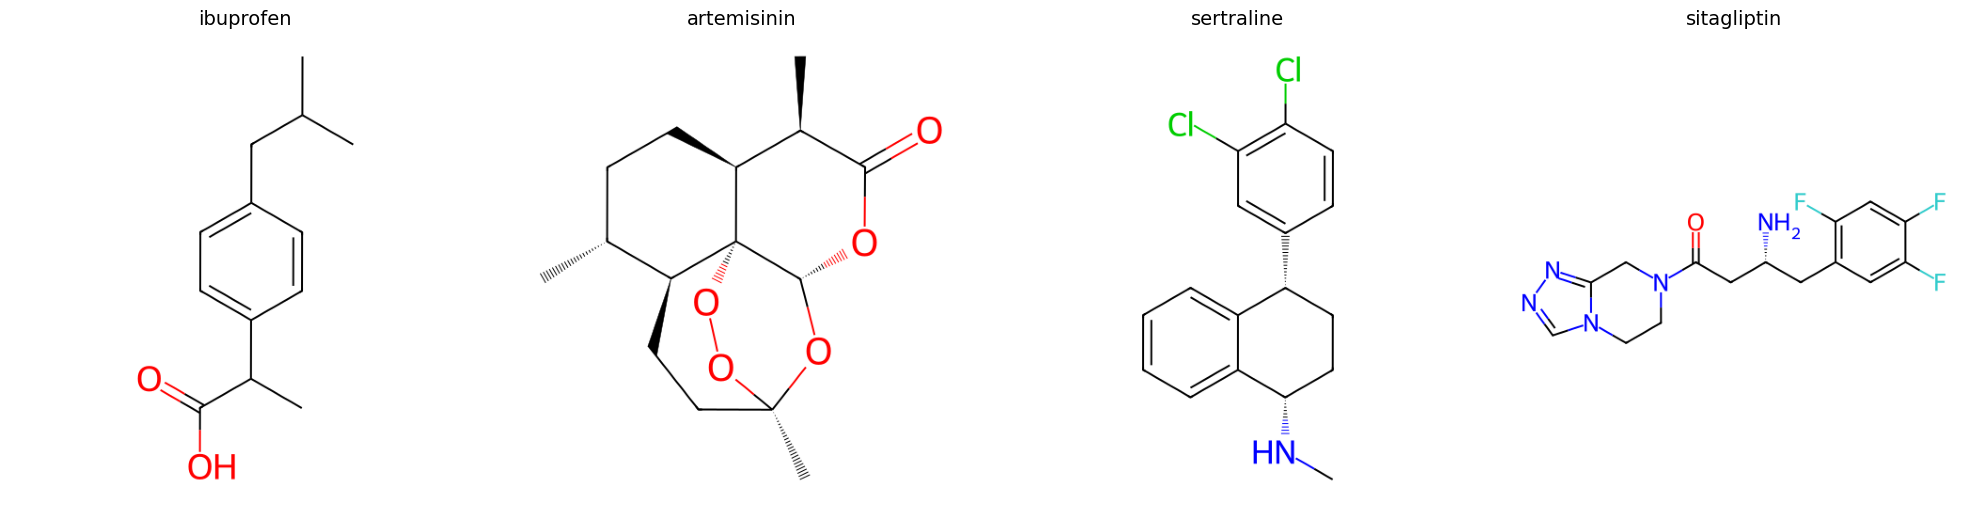

In [13]:
import importlib
import jupyter_functions
importlib.reload(jupyter_functions)
from jupyter_functions import show_smiles_grid

show_smiles_grid()

### **Pathway comparison**

After viewing the molecular structure of the pharmaceutical molecule, the user can scroll down to access the “Pathway comparison” table. It contains the available synthesis pathways for the selected molecule and the green metrics associated. The displayed metrics include: 
- atom economy
- PMI
- E-factor
- overall yield, 
- number of steps
- hazard score 
- solvent profile. 

The function highlight_best_worst() is used to highlight the best values in green and the worst in orange. This allows rapid comparison between synthesis pathways without analysing each numerical value. As displayed on the screen, higher atom economy and overall yield values are considered more favorable, while lower PMI, E-factor, number of steps and hazard score values are preferred.

This comparison helps decision-making by bringing several sustainability metrics together in one clear view, making it easier to compare efficiency, waste production, and safety between the different pathways.

The Jupyter notebook reproduces the same pathway comparison logic as the Streamlit application by filtering the dataset, selecting relevant green chemistry metrics, and structuring them into a comparative table for analysis:

In [7]:
import importlib
import jupyter_functions
importlib.reload(jupyter_functions)
from jupyter_functions import load_results, get_mol_df, show_comparison_table

results_df = load_results()
mol_df = get_mol_df(results_df, "Sitagliptin")
table_df = show_comparison_table(mol_df)
table_df

,Pathway,Atom economy (%),PMI,E-factor,Overall yield (%),Steps,Hazard score
6,Merck 2nd-generation sitagliptin process,73.97,2.12,1.12,67.50,5,3.0
7,Merck/Codexis 3rd-generation biocatalytic sita...,90.01,1.28,0.28,76.28,2,1.6


### **Pathway spider chart**

A pathway radar chart was added to allow visual comparison of all pathways across multiple metrics simultaneously. Each axis corresponds to one green chemistry metric, and each pathway is drawn as a separate line using Plotly's go.Scatterpolar.

Because the metrics have different units and scales, the values are normalized before plotting. For each metric, the minimum and maximum values across all pathways are used to rescale values to a range between 0.15 and 1.0. The lower bound of 0.15 ensures that even the worst-performing pathway remain visible on the chart. For metrics where lower values are better from a green chemistry point of view (PMI, E-factor, number of steps, hazard score), the normalization is inverted, so that the outer edge of the chart represents the better performance on all axes. 

The radar_metrics dictionary defines which metrics are included and whether higher or lower is better for each. This controls the way the metric will be normalized. 

The following code reproduces this chart in the notebook using table_df built in the previous cell:

In [10]:
import importlib
import jupyter_functions
importlib.reload(jupyter_functions)
from jupyter_functions import show_radar_chart

fig = show_radar_chart(table_df)
fig.show()

### **Inspection of one particular pathway**

After consulting the comparison table and radar chart, the user can inspect a specific synthesis pathway in detail. This section provides a more focused view of a single route, bringing together all relevant information in one place.

For the selected route, the interface first displays the reaction scheme, giving a visual overview of the synthetic steps involved. The function get_reaction_scheme_path() retrieves the reaction the reaction scheme image by searching for keywords from the route name in a dictionary that maps each route to its corresponding image file.

Below the scheme, six green chemistry metrics are displayed in a three-column layout using st.metric(): atom economy, PMI, E-factor, overall yield, number of steps and hazard score. For some routes, the raw reaction data needed to directly calculate the green chemistry metrics was not fully available. In these cases, values from the literature were used instead, and a warning is displayed to inform the user.

Finally, the overall solvent profile is displayed as a colored label indicating its environmental impact: green for recommended solvents, orange for moderate impact, and red for hazardous or problematic solvents. 

The following code reproduces this pathway inspection in the notebook. The two Sitagliptin routes are shown as examples:

Inspecting route: Merck 2nd-generation sitagliptin process



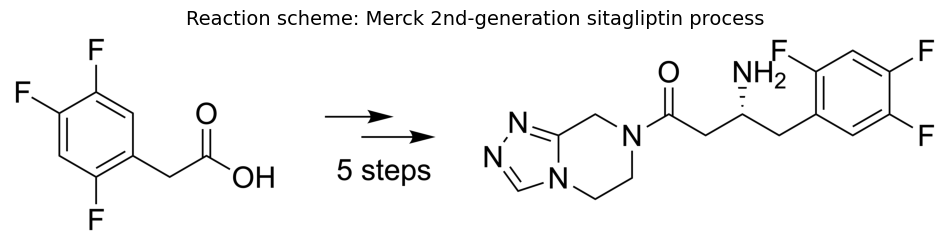

Atom economy (%): 73.97%
PMI: 2.12
E-factor: 1.12
Overall yield (%): 67.50%
Steps: 5
Hazard score: 3.00

Solvent impact: Unavailable
Inspecting route: Merck/Codexis 3rd-generation biocatalytic sitagliptin process



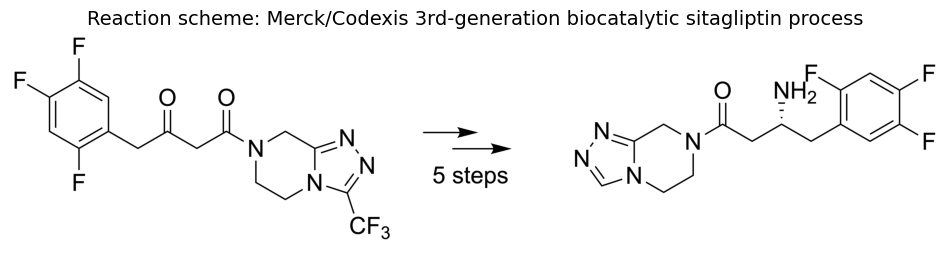

Atom economy (%): 90.01%
PMI: 1.28
E-factor: 0.28
Overall yield (%): 76.28%
Steps: 2
Hazard score: 1.60

Solvent impact: Unavailable


In [11]:
import importlib
import jupyter_functions
importlib.reload(jupyter_functions)
from jupyter_functions import show_route_inspection

show_route_inspection(mol_df, route_index=0)
show_route_inspection(mol_df, route_index=1)

## **Discussion**

### **Interpretation of results**
### **Challenges encountered**

The biggest challenge encountered during the project was the creation of a reliable and usable dataset. Data related to pharmaceutical synthesis pathways is both limited and highly dispersed across academic literature, patents, and industrial publications, and when available, it is rarely reported under standardized conditions. So many of the values had to first be standardized in order to allow for coherent comparison between the different pathways. Since the dataset was compiled from multiple scientific sources, the four molecules included in the project represent the realistic scope that could be achieved within the available time. However, the workbook structure was designed so that chemical engineers or researchers can easily input their own experimental or industrial data into the system for future route comparisons.
Another important challenge was the presence of missing or incomplete values in several literature sources. In these cases, reference values reported directly in the publications were used when available instead of leaving empty fields or attempting unreliable recalculations. These values are clearly identified on the website whenever a metric originates from external literature rather than being computed directly by the system.
A further difficulty was integrating the different technologies used throughout the pipeline, including Pandas, openpyxl, RDKit, and Streamlit, into one coherent workflow extending from data loading to final visualization. In addition, deciding how to organise and structure the chemistry data was also a challenge. The final dataclass-based structure using Route, Step, and Material objects was selected because it follows the natural organisation of a synthesis pathway while keeping the data clear, easy to manage, and practical for calculations throughout the project.

### **Limitations of GreenRoute**

One of the main limitations of GreenRoute is its simplified representation of chemical synthesis pathways. The system mainly models reactions through steps, materials, and green chemistry metrics, but real industrial synthesis is also influenced by many additional factors such as temperature, pressure, reaction time and many others  which are not currently included in the model. As a result, the calculated metrics represent simplified pathway evaluations rather than the full complexity of real chemical manufacturing.
Another limitation is that the platform focuses primarily on sustainability indicators and does not currently account for important industrial factors such as production cost, scalability, energy consumption, or manufacturing speed. Therefore, the route identified as the “greenest” may not always be the most practical or economically viable option at industrial scale. These could potentially be implemented by creating new functions and extending the code.
Finally, the dataset used in GreenRoute must currently be collected and verified manually from scientific literature. This makes the process time-consuming and increases the possibility of missing values, inconsistencies, or human error within the dataset.
